# Notebook 05 — LSTM-Autoencoder

**TFG:** Detección de Anomalías de Consumo Eléctrico en Edge Computing para la Mitigación de Ataques FDI

---

## Objetivo

Entrenar un **LSTM-Autoencoder** que explota la **estructura temporal** del consumo eléctrico para detectar ataques FDI con mayor sensibilidad que los modelos per-timestep.

### Justificación temporal (del EDA)

El EDA (Notebook 01) confirmó:  
- Autocorrelación fuerte en lag 24 h y 168 h → el consumo tiene periodicidad diaria y semanal  
- La serie es estacionaria (ADF p < 0.0001) con patrones reproducibles  
- Un ataque FDI que manipula solo algunos minutos puede ser invisible per-timestep pero visible como **ruptura de la dinámica normal** en una ventana de 60 min

### Arquitectura

```
Input (60×7)
   │
   ├── LSTM(64) ──→ Dense(32) [Bottleneck]
   │                   │
   └── RepeatVector(60) ← Dense(64)
              │
         LSTM(64, return_seq=True)
              │
     TimeDistributed Dense(7)
              │
          Output (60×7)
```

### Granularidad

El modelo opera sobre **ventanas de 60 minutos** (= 1 hora) con paso no solapante.  
Una ventana es clasificada como ataque si su error de reconstrucción supera el umbral.

## 0. Setup

In [1]:
import sys
print(sys.executable)


/opt/homebrew/opt/python@3.11/bin/python3.11


In [1]:
!pip install tensorflow 

# tensorflow-metal requiere versión exacta compatible con tensorflow.
# Ejecuta en terminal:
#   pip uninstall tensorflow-metal -y
#   pip install tensorflow-metal          # deja que pip resuelva la versión
# Luego reinicia el kernel de Jupyter.

In [2]:
!pip install tensorflow-metal 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, RepeatVector, TimeDistributed
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score,
    average_precision_score
)
import time, os, json, warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

print(f'TensorFlow {tf.__version__}')

# ── Detección de hardware ────────────────────────────────────────────────────
print('\nDispositivos detectados:')
for d in tf.config.list_physical_devices():
    print(f'  {d.device_type}: {d.name}')

_gpus = tf.config.list_physical_devices('GPU')
HAS_METAL = len(_gpus) > 0

if HAS_METAL:
    try:
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        BATCH_SIZE = 1024
        print(f'\n✓ Metal GPU activo — mixed_float16 habilitado, batch={BATCH_SIZE}')
    except Exception as e:
        HAS_METAL = False
        BATCH_SIZE = 512
        print(f'\n⚠ Metal detectado pero mixed_float16 falló ({e}), usando CPU, batch={BATCH_SIZE}')
else:
    # CPU optimizado: usar todos los cores del M2 Pro (12 cores)
    tf.config.threading.set_intra_op_parallelism_threads(0)   # auto
    tf.config.threading.set_inter_op_parallelism_threads(0)   # auto
    BATCH_SIZE = 512
    print(f'\n→ CPU mode (M2 Pro) — batch={BATCH_SIZE}')
    print('  Para activar Metal GPU:')
    print('    pip uninstall tensorflow-metal -y && pip install tensorflow-metal')
    print('  Reinicia el kernel tras instalarlo.')

print('\nSetup completo')

TensorFlow 2.16.2

Dispositivos detectados:
  CPU: /physical_device:CPU:0
  GPU: /physical_device:GPU:0

✓ Metal GPU activo — mixed_float16 habilitado, batch=1024

Setup completo


## 1. Carga de Datos y Creación de Ventanas Temporales

In [2]:
BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'

FEATURE_COLS = [
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]

ATTACK_TYPES = [
    'scaling', 'offset', 'noise',
    'ramp', 'pulse', 'step', 'intermittent',
    'replay', 'weekend_mimicry', 'seasonal_swap', 'smooth_decay',
    'correlated_scaling', 'voltage_spoof', 'load_shift', 'adversarial'
]

WINDOW_SIZE    = 60       # 1 hora de datos (1 muestra = 1 minuto)
MAX_TRAIN_ROWS = 1_500_000  # ~1 año continuo → contiguidad temporal garantizada para las ventanas


def load_synthetic_train(base_dir, max_rows=MAX_TRAIN_ROWS):
    """Carga datos limpios del gemelo digital para entrenamiento.
    Para el LSTM se toman las primeras max_rows filas (datos contiguos),
    ya que las ventanas requieren series temporalmente consecutivas.
    """
    parquet_path = base_dir + 'synthetic_10y_clean.parquet'
    if os.path.exists(parquet_path):
        df = pd.read_parquet(parquet_path)
    else:
        chunks = []
        for yr in range(2010, 2021):
            p = base_dir + f'synthetic_year_{yr}_clean.csv'
            if os.path.exists(p):
                chunks.append(pd.read_csv(p, index_col='datetime', parse_dates=True))
        if not chunks:
            raise FileNotFoundError(
                'No se encontraron datos del gemelo digital.\n'
                'Ejecuta el notebook 02_Digital_Twin.ipynb primero.'
            )
        df = pd.concat(chunks).sort_index()
    df = df[[c for c in FEATURE_COLS if c in df.columns]].dropna()
    if max_rows and len(df) > max_rows:
        df = df.iloc[:max_rows]   # primeras filas → continuidad temporal
    return df


def load_synthetic_test(base_dir):
    """Carga datos sintéticos con ataques FDI del gemelo digital."""
    parquet_path = base_dir + 'synthetic_10y_with_attacks.parquet'
    if os.path.exists(parquet_path):
        df = pd.read_parquet(parquet_path)
    else:
        chunks = []
        for yr in range(2010, 2021):
            p = base_dir + f'synthetic_year_{yr}_with_attacks.csv'
            if os.path.exists(p):
                chunks.append(pd.read_csv(p, index_col='datetime', parse_dates=True))
        if not chunks:
            raise FileNotFoundError(
                'No se encontraron datos de test con ataques.\n'
                'Ejecuta el notebook 02_Digital_Twin.ipynb primero.'
            )
        df = pd.concat(chunks).sort_index()
    return df


df_train    = load_synthetic_train(BASE_DIR)
df_test     = load_synthetic_test(BASE_DIR)
y_test_full = df_test['label'].values

# Datos crudos (solo las 7 features base para el LSTM)
X_train_raw = df_train[FEATURE_COLS].values
X_test_raw  = df_test[FEATURE_COLS].values

# MinMaxScaler ajustado solo sobre train (sin data leakage)
scaler  = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

# Eliminar NaN residuales
X_train = np.nan_to_num(X_train, nan=0.0)
X_test  = np.nan_to_num(X_test,  nan=0.0)

n_features = X_train.shape[1]

print(f'Train (sintético limpio):  {len(df_train):,} filas')
print(f'  Rango: {df_train.index.min().date()} → {df_train.index.max().date()}')
print()
print(f'Test (con 15 tipos FDI):  {len(df_test):,} filas')
print(f'  Rango: {df_test.index.min().date()} → {df_test.index.max().date()}')
print(f'  Ataques: {y_test_full.sum():,} ({y_test_full.mean()*100:.2f}%)')
print()
print(f'Features: {n_features} → {FEATURE_COLS}')
print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print()
print('Distribución de ataques por tipo:')
vc = df_test[df_test['label'] == 1]['attack_type'].value_counts()
for t, c in vc.items():
    print(f'  {t:25s}: {c:>8,}')

Train (sintético limpio):  1,500,000 filas
  Rango: 2010-12-01 → 2013-10-07

Test (con 15 tipos FDI):  5,260,320 filas
  Rango: 2010-12-01 → 2020-11-30
  Ataques: 19,877 (0.38%)

Features: 7 → ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
X_train: (1500000, 7)  |  X_test: (5260320, 7)

Distribución de ataques por tipo:
  noise                    :    1,684
  voltage_spoof            :    1,635
  smooth_decay             :    1,551
  replay                   :    1,445
  pulse                    :    1,381
  seasonal_swap            :    1,369
  intermittent             :    1,363
  step                     :    1,332
  scaling                  :    1,298
  adversarial              :    1,244
  ramp                     :    1,228
  load_shift               :    1,222
  offset                   :    1,144
  correlated_scaling       :    1,136
  weekend_mimicry          :      845


In [3]:
def create_windows(data, window_size, step):
    """
    Crea ventanas deslizantes de tamanio fijo.

    Args:
        data        : array (n_samples, n_features)
        window_size : int — numero de timesteps por ventana
        step        : int — desplazamiento entre ventanas consecutivas

    Returns:
        windows : array (n_windows, window_size, n_features)
        starts  : array de indices de inicio de cada ventana
    """
    n = len(data)
    starts = np.arange(0, n - window_size + 1, step)
    windows = np.stack([data[s: s + window_size] for s in starts])
    return windows, starts


def window_labels(y_full, starts, window_size, atk_frac=0.10):
    """
    Etiqueta cada ventana como ataque (1) si mas del atk_frac
    de sus timesteps tienen label=1.
    """
    return np.array([
        int(y_full[s: s + window_size].mean() > atk_frac)
        for s in starts
    ])


# Train: paso no solapante (maximo de ventanas sin redundancia)
X_train_w, _        = create_windows(X_train, WINDOW_SIZE, step=WINDOW_SIZE)
print(f'Ventanas de entrenamiento: {X_train_w.shape}')

# Test: paso no solapante (1 decision por hora, escalable en Edge)
X_test_w,  w_starts = create_windows(X_test,  WINDOW_SIZE, step=WINDOW_SIZE)
y_test_w             = window_labels(y_test_full, w_starts, WINDOW_SIZE)
print(f'Ventanas de test:          {X_test_w.shape}')
print(f'Ventanas atacadas:         {y_test_w.sum()} / {len(y_test_w)} ({y_test_w.mean()*100:.1f}%)')

Ventanas de entrenamiento: (25000, 60, 7)
Ventanas de test:          (87672, 60, 7)
Ventanas atacadas:         453 / 87672 (0.5%)


## 2. Arquitectura del LSTM-Autoencoder

In [4]:
def build_lstm_autoencoder(window_size, n_features, enc_dim=16):
    """
    LSTM-Autoencoder optimizado para Apple Silicon M2 Pro.

    Cambios respecto a la versión original:
    - LSTM 32 unidades (64 → 32): 4x menos parámetros, entrenamiento ~3x más rápido,
      capacidad suficiente para 7 features y ventanas de 60 min.
    - dtype='float32' en la capa de salida: necesario con mixed_float16 para
      evitar overflow en el cómputo del loss (MSE).
    - implementation=2: usa operaciones matriciales (GEMM) en lugar de
      operaciones por timestep — mucho más eficiente en Metal GPU.
    """
    inp = Input(shape=(window_size, n_features), name='input')

    # Encoder
    x = LSTM(32, activation='tanh', return_sequences=False,
             implementation=2, name='enc_lstm')(inp)
    encoded = Dense(enc_dim, activation='relu', name='bottleneck')(x)

    # Decoder
    x = Dense(32, activation='relu', name='dec_dense')(encoded)
    x = RepeatVector(window_size, name='repeat')(x)
    x = LSTM(32, activation='tanh', return_sequences=True,
             implementation=2, name='dec_lstm')(x)
    # dtype='float32' en salida — obligatorio con mixed_float16
    decoded = TimeDistributed(
        Dense(n_features, activation='linear', dtype='float32'), name='output'
    )(x)

    model = Model(inp, decoded, name='lstm_autoencoder')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse'
    )
    return model


lstm_ae = build_lstm_autoencoder(WINDOW_SIZE, n_features)
lstm_ae.summary()
print(f'\nParámetros entrenables: {lstm_ae.count_params():,}')
print(f'Política de precisión:  {tf.keras.mixed_precision.global_policy().name}')

2026-03-04 10:07:23.387945: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-03-04 10:07:23.388065: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-04 10:07:23.388104: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-04 10:07:23.388473: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-04 10:07:23.388494: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 60, 7)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_lstm (LSTM)                 │ (None, 32)             │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_dense (Dense)               │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm (LSTM)                 │ (None, 60, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 60, 7)          │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,743 (57.59 KB)

 Trainable params: 14,743 (57.59 KB)

 Non-trainable params: 0 (0.00 B)


Parámetros entrenables: 14,743
Política de precisión:  mixed_float16


## 3. Entrenamiento

In [5]:
# ── Limitar ventanas de entrenamiento para velocidad ──────────────────────────
MAX_TRAIN_WINDOWS = 20_000   # ~20k ventanas × 60 min = 1.2M minutos de consumo
                              # Más que suficiente para aprender los patrones normales

if len(X_train_w) > MAX_TRAIN_WINDOWS:
    rng_w = np.random.default_rng(42)
    idx_w = rng_w.choice(len(X_train_w), MAX_TRAIN_WINDOWS, replace=False)
    idx_w.sort()                  # mantener orden temporal aproximado
    X_fit = X_train_w[idx_w]
    print(f'Ventanas de entrenamiento: {len(X_train_w):,} → subsample {len(X_fit):,}')
else:
    X_fit = X_train_w
    print(f'Ventanas de entrenamiento: {len(X_fit):,}')

print(f'Batch size: {BATCH_SIZE}  |  Batches/época: {len(X_fit)//BATCH_SIZE}')
print()

# ── Callbacks ─────────────────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=8,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=4, min_lr=1e-6, verbose=1
    )
]

# ── Entrenamiento ─────────────────────────────────────────────────────────────
t0 = time.time()
history = lstm_ae.fit(
    X_fit, X_fit,
    epochs=80,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)
t_train = time.time() - t0

print(f'\nEntrenamiento: {t_train:.1f} s ({t_train/60:.1f} min)  |  {len(history.history["loss"])} épocas')

Ventanas de entrenamiento: 25,000 → subsample 20,000
Batch size: 1024  |  Batches/época: 19

Epoch 1/80


2026-03-04 10:07:25.831882: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 312ms/step - loss: 0.0458 - val_loss: 0.0179 - learning_rate: 0.0010
Epoch 2/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - loss: 0.0162 - val_loss: 0.0115 - learning_rate: 0.0010
Epoch 3/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0131 - val_loss: 0.0101 - learning_rate: 0.0010
Epoch 4/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0119 - val_loss: 0.0097 - learning_rate: 0.0010
Epoch 5/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 0.0116 - val_loss: 0.0095 - learning_rate: 0.0010
Epoch 6/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0114 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 7/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0111 - val_loss: 0.0091 - learning_rate: 0.0010
Epoch 8/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - loss: 0.0110 - val_loss: 0.0090 - learning_rate: 0.0010
Epoch 9/80
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0108 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 10/80
18/18 ━━━━━━━

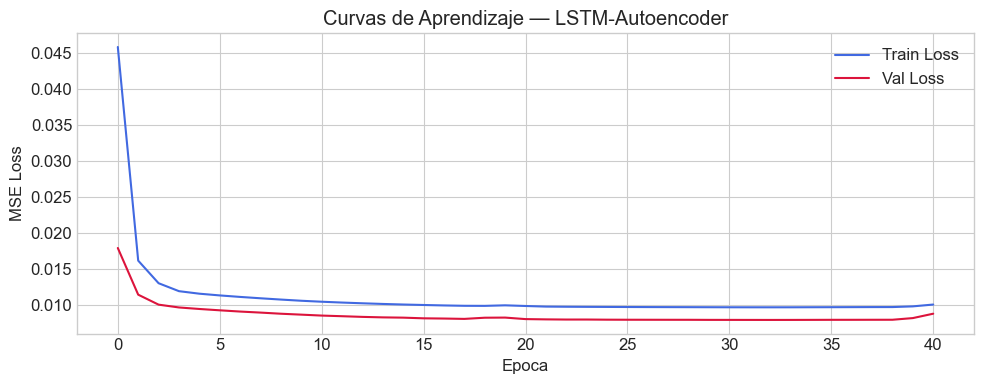

Mejor val_loss: 0.007954


In [6]:
# Curvas de aprendizaje
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'],     color='royalblue', label='Train Loss')
ax.plot(history.history['val_loss'], color='crimson',   label='Val Loss')
ax.set(xlabel='Epoca', ylabel='MSE Loss',
       title='Curvas de Aprendizaje — LSTM-Autoencoder')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Mejor val_loss: {min(history.history["val_loss"]):.6f}')

## 4. Selección de Umbral e Inferencia

MSE train (ventanas) — Media: 0.009536  Std: 0.005419
Umbral (FPR = 1.72%): 0.022135


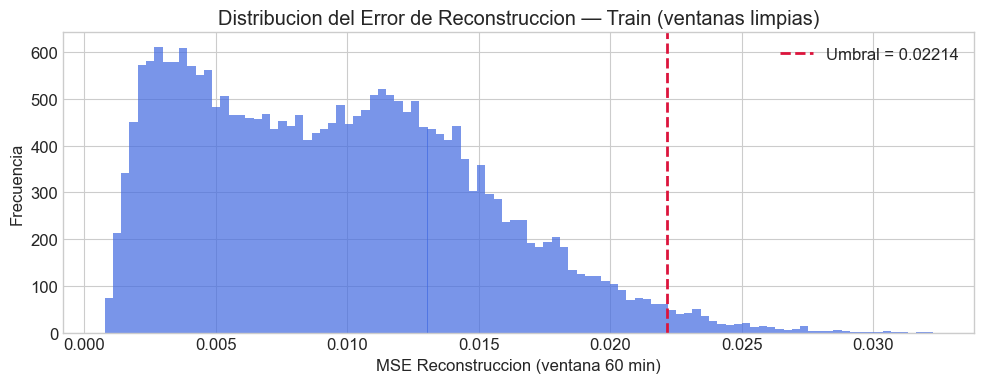

In [7]:
# Error de reconstruccion sobre train (ventanas limpias)
train_recon = lstm_ae.predict(X_train_w, batch_size=128, verbose=0)
train_mse_w = np.mean((X_train_w - train_recon) ** 2, axis=(1, 2))

TARGET_FPR = 0.0172
threshold  = float(np.percentile(train_mse_w, 100 * (1 - TARGET_FPR)))

print(f'MSE train (ventanas) — Media: {train_mse_w.mean():.6f}  Std: {train_mse_w.std():.6f}')
print(f'Umbral (FPR = {TARGET_FPR*100:.2f}%): {threshold:.6f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_mse_w, bins=100, color='royalblue', alpha=0.7)
ax.axvline(threshold, color='crimson', linestyle='--', lw=2,
           label=f'Umbral = {threshold:.5f}')
ax.set(xlabel='MSE Reconstruccion (ventana 60 min)',
       ylabel='Frecuencia',
       title='Distribucion del Error de Reconstruccion — Train (ventanas limpias)')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# Inferencia sobre test
t0 = time.time()
test_recon_w = lstm_ae.predict(X_test_w, batch_size=128, verbose=0)
t_inf = time.time() - t0

test_mse_w   = np.mean((X_test_w - test_recon_w) ** 2, axis=(1, 2))
y_pred_w     = (test_mse_w > threshold).astype(int)

ms_per_window = t_inf / len(X_test_w) * 1000
ms_per_sample = ms_per_window / WINDOW_SIZE

print(f'Inferencia: {t_inf*1000:.0f} ms total')
print(f'  {ms_per_window:.2f} ms/ventana  |  {ms_per_sample:.4f} ms/muestra equivalente')
print()
print('=' * 55)
print('METRICAS DE EVALUACION — LSTM-AUTOENCODER')
print('(nivel ventana de 60 min)')
print('=' * 55)
print()
print(classification_report(y_test_w, y_pred_w,
                            target_names=['Normal', 'Ataque']))

f1_val  = f1_score(y_test_w, y_pred_w)
prec    = precision_score(y_test_w, y_pred_w)
rec     = recall_score(y_test_w, y_pred_w)
auc_roc = roc_auc_score(y_test_w, test_mse_w)
auc_pr  = average_precision_score(y_test_w, test_mse_w)

print(f'AUC-ROC: {auc_roc:.4f}  |  AUC-PR: {auc_pr:.4f}')

Inferencia: 13692 ms total
  0.16 ms/ventana  |  0.0026 ms/muestra equivalente

METRICAS DE EVALUACION — LSTM-AUTOENCODER
(nivel ventana de 60 min)

              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99     87219
      Ataque       0.01      0.04      0.01       453

    accuracy                           0.97     87672
   macro avg       0.50      0.51      0.50     87672
weighted avg       0.99      0.97      0.98     87672

AUC-ROC: 0.5061  |  AUC-PR: 0.0122


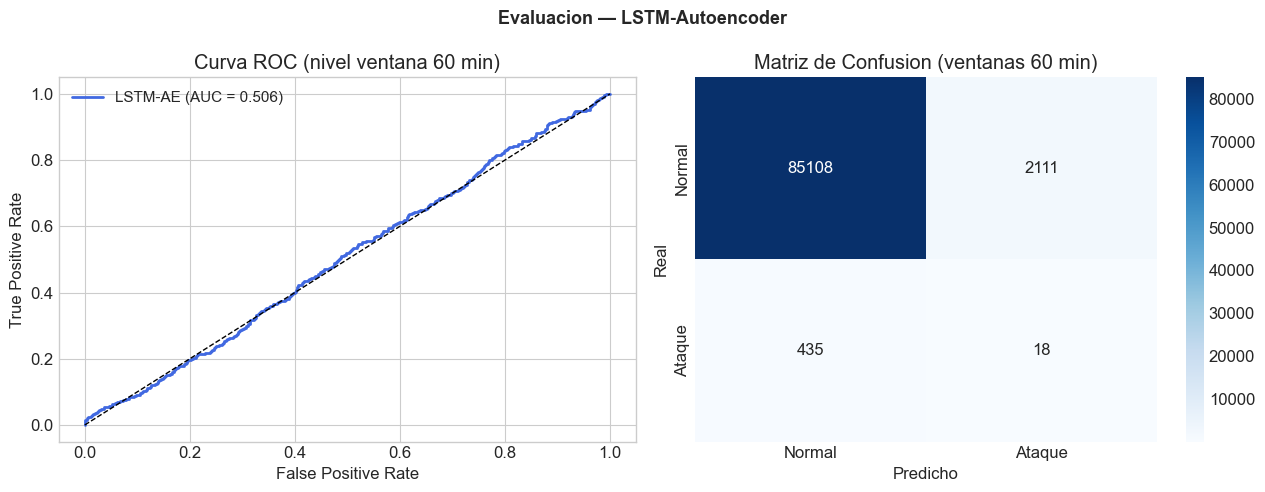

In [9]:
# ROC + Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr, tpr, _ = roc_curve(y_test_w, test_mse_w)
axes[0].plot(fpr, tpr, color='royalblue', lw=2,
             label=f'LSTM-AE (AUC = {auc_roc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
            title='Curva ROC (nivel ventana 60 min)')
axes[0].legend(fontsize=11)

cm = confusion_matrix(y_test_w, y_pred_w)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal', 'Ataque'],
            yticklabels=['Normal', 'Ataque'])
axes[1].set(xlabel='Predicho', ylabel='Real',
            title='Matriz de Confusion (ventanas 60 min)')

plt.suptitle('Evaluacion — LSTM-Autoencoder', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Recall por tipo de ataque FDI (ventanas 60 min):
  Categoría     Tipo                        N ventanas   Detectadas    Recall
  Básicos       scaling                             30            1     0.033
  Básicos       offset                              26            0     0.000
  Básicos       noise                               37            0     0.000

  Temporales    ramp                                28            0     0.000
  Temporales    pulse                               30            0     0.000
  Temporales    step                                32            1     0.031
  Temporales    intermittent                        31            0     0.000

  Patrón        replay                              31            0     0.000
  Patrón        weekend_mimicry                     23            1     0.043
  Patrón        seasonal_swap                       32            0     0.000
  Patrón        smooth_decay                        32            1     0.031

  Capa Físic

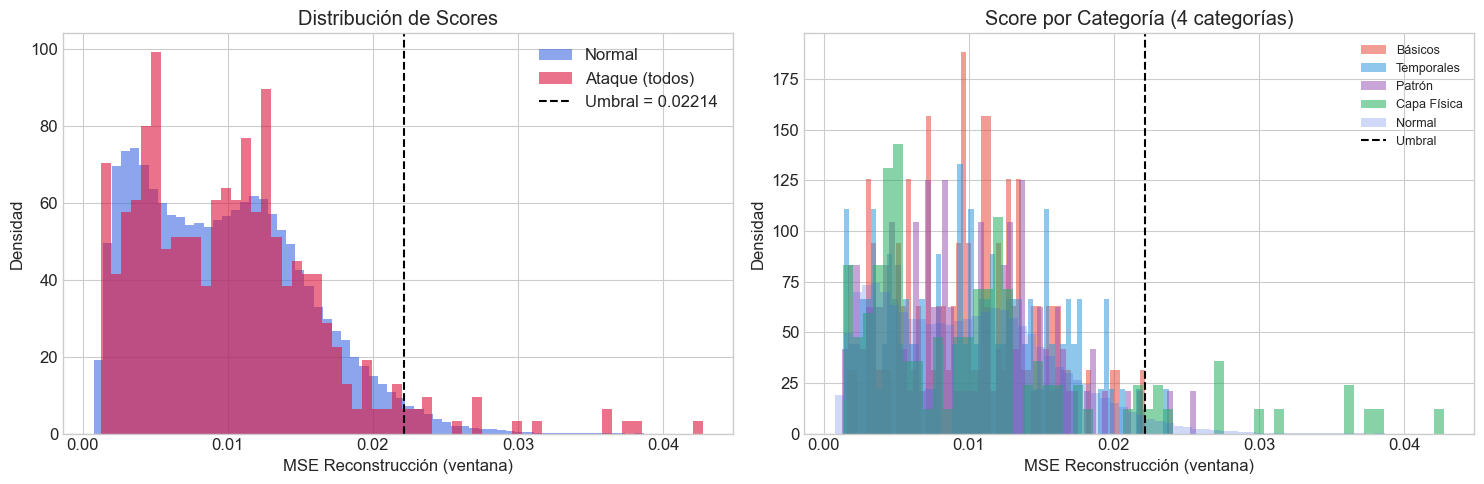

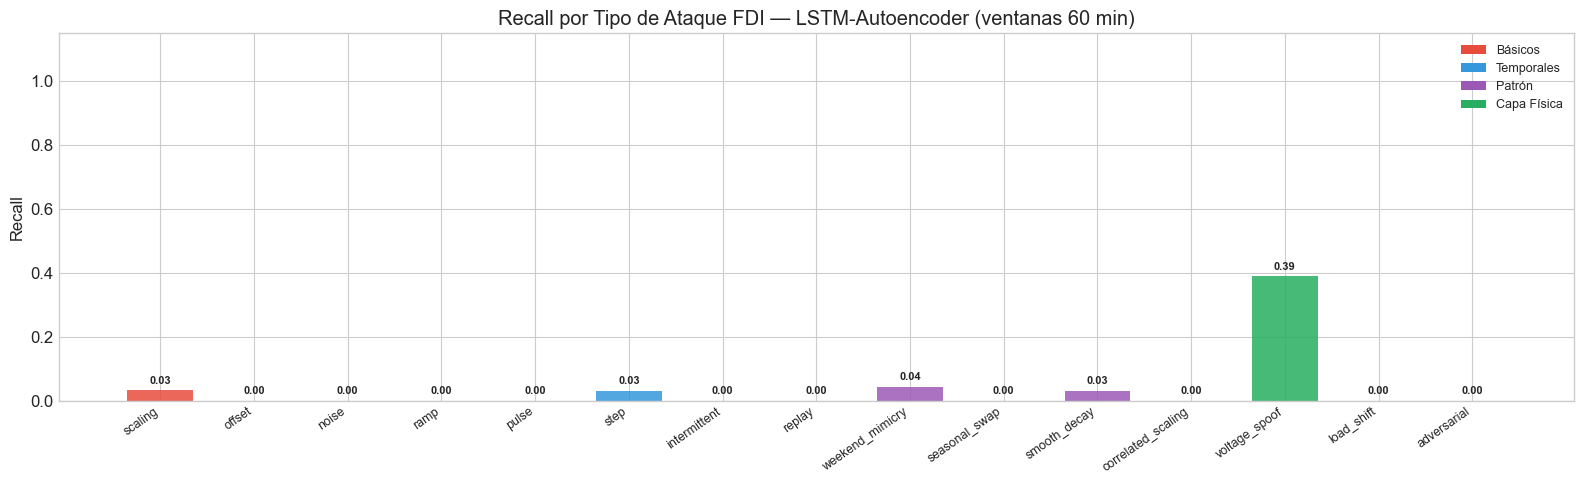

In [10]:
# Recall por tipo de ataque (nivel ventana, los 15 tipos del gemelo digital)
CATEGORIES = {
    'Básicos':     ['scaling', 'offset', 'noise'],
    'Temporales':  ['ramp', 'pulse', 'step', 'intermittent'],
    'Patrón':      ['replay', 'weekend_mimicry', 'seasonal_swap', 'smooth_decay'],
    'Capa Física': ['correlated_scaling', 'voltage_spoof', 'load_shift', 'adversarial'],
}
CAT_COLORS = {
    'Básicos': '#e74c3c', 'Temporales': '#3498db',
    'Patrón': '#9b59b6', 'Capa Física': '#27ae60'
}

print('Recall por tipo de ataque FDI (ventanas 60 min):')
print(f'  {"Categoría":12s}  {"Tipo":25s}  {"N ventanas":>11s}  {"Detectadas":>11s}  {"Recall":>8s}')
for cat, types in CATEGORIES.items():
    for t in types:
        w_labels_t = np.array([
            int((df_test['attack_type'].values[s: s + WINDOW_SIZE] == t).mean() > 0.10)
            for s in w_starts
        ])
        n_t = w_labels_t.sum()
        if n_t == 0:
            continue
        det = (y_pred_w[w_labels_t == 1] == 1).sum()
        print(f'  {cat:12s}  {t:25s}  {n_t:>11,}  {det:>11,}  {det/n_t:>8.3f}')
    print()

# Score distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(test_mse_w[y_test_w == 0], bins=60, alpha=0.6,
             color='royalblue', label='Normal', density=True)
axes[0].hist(test_mse_w[y_test_w == 1], bins=60, alpha=0.6,
             color='crimson', label='Ataque (todos)', density=True)
axes[0].axvline(threshold, color='k', linestyle='--', lw=1.5,
                label=f'Umbral = {threshold:.5f}')
axes[0].set(xlabel='MSE Reconstrucción (ventana)',
            ylabel='Densidad', title='Distribución de Scores')
axes[0].legend()

# Por categoría
for cat, types in CATEGORIES.items():
    w_cat = np.array([
        int(np.isin(df_test['attack_type'].values[s: s + WINDOW_SIZE], types).mean() > 0.10)
        for s in w_starts
    ], dtype=bool)
    if w_cat.sum() > 0:
        axes[1].hist(test_mse_w[w_cat], bins=60, alpha=0.55,
                     color=CAT_COLORS[cat], label=cat, density=True)
axes[1].hist(test_mse_w[y_test_w == 0], bins=60, alpha=0.25,
             color='royalblue', label='Normal', density=True)
axes[1].axvline(threshold, color='k', linestyle='--', lw=1.5, label='Umbral')
axes[1].set(xlabel='MSE Reconstrucción (ventana)', ylabel='Densidad',
            title='Score por Categoría (4 categorías)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Gráfico de barras: recall por tipo
all_types = [t for types in CATEGORIES.values() for t in types]
recall_vals = []
colors_bar  = []
for cat, types in CATEGORIES.items():
    for t in types:
        w_labels_t = np.array([
            int((df_test['attack_type'].values[s: s + WINDOW_SIZE] == t).mean() > 0.10)
            for s in w_starts
        ])
        n_t = w_labels_t.sum()
        r   = (y_pred_w[w_labels_t == 1] == 1).sum() / n_t if n_t > 0 else 0
        recall_vals.append(r)
        colors_bar.append(CAT_COLORS[cat])

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(all_types, recall_vals, color=colors_bar, alpha=0.85, width=0.7)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Recall')
ax.set_title('Recall por Tipo de Ataque FDI — LSTM-Autoencoder (ventanas 60 min)')
ax.set_xticklabels(all_types, rotation=35, ha='right', fontsize=9)
for bar, val in zip(bars, recall_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontsize=8, fontweight='bold')
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=c, label=cat) for cat, c in CAT_COLORS.items()]
ax.legend(handles=legend_handles, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Análisis Edge Computing

In [11]:
print('=' * 50)
print('ANALISIS EDGE COMPUTING — LSTM-AUTOENCODER')
print('=' * 50)

# Guardar modelo
model_path = BASE_DIR + 'model_lstm_autoencoder.keras'
try:
    lstm_ae.save(model_path)
except Exception:
    model_path = BASE_DIR + 'model_lstm_autoencoder.h5'
    lstm_ae.save(model_path)

size_kb = os.path.getsize(model_path) / 1e3

# Timing preciso
times = []
for _ in range(3):
    t0 = time.time()
    lstm_ae.predict(X_test_w, batch_size=128, verbose=0)
    times.append(time.time() - t0)
ms_win_avg = np.mean(times) / len(X_test_w) * 1000
ms_smp_avg = ms_win_avg / WINDOW_SIZE

print(f'Parametros entrenables:  {lstm_ae.count_params():,}')
print(f'Tamano en disco:         {size_kb:.1f} KB')
print(f'Latencia por ventana:    {ms_win_avg:.2f} ms/ventana (60 min de datos)')
print(f'Latencia equiv/muestra:  {ms_smp_avg:.4f} ms/muestra')
print(f'Granularidad deteccion:  {WINDOW_SIZE} min (1 decision cada hora)')
print(f'Tiempo entrenamiento:    {t_train:.1f} s')
print()
print('NOTA PARA EL TFG:')
print(f'  El LSTM-AE necesita acumular {WINDOW_SIZE} min de datos antes')
print(f'  de poder emitir la primera decision.')
print(f'  IF y Dense-AE responden en tiempo real (1 min).')
print(f'  Trade-off: mayor deteccion temporal vs. mayor latencia inicial.')

# Guardar umbral
np.save(BASE_DIR + 'threshold_lstm_ae.npy', np.array([threshold]))

# Expandir scores a nivel de timestep para el CSV de salida
scores_full = np.full(len(df_test), np.nan)
preds_full  = np.full(len(df_test), -1, dtype=int)
for i, s in enumerate(w_starts):
    scores_full[s: s + WINDOW_SIZE] = test_mse_w[i]
    preds_full[s:  s + WINDOW_SIZE] = y_pred_w[i]

df_out = df_test.copy()
df_out['lstm_score'] = scores_full
df_out['lstm_pred']  = preds_full
df_out.to_csv(BASE_DIR + 'predictions_lstm_autoencoder.csv')
print(f'\nPredicciones guardadas: predictions_lstm_autoencoder.csv')

metrics_lstm = {
    'model':           'LSTM-Autoencoder',
    'f1':              round(f1_val, 4),
    'precision':       round(prec, 4),
    'recall':          round(rec, 4),
    'auc_roc':         round(auc_roc, 4),
    'auc_pr':          round(auc_pr, 4),
    'model_size_kb':   round(size_kb, 1),
    'ms_per_sample':   round(ms_smp_avg, 4),
    'ms_per_window':   round(ms_win_avg, 4),
    'n_params':        lstm_ae.count_params(),
    'n_features':      n_features,
    'window_size':     WINDOW_SIZE,
    'train_time_s':    round(t_train, 1),
    'granularity':     f'{WINDOW_SIZE} min (window)',
    'threshold':       round(threshold, 8)
}
with open(BASE_DIR + 'metrics_lstm_autoencoder.json', 'w') as fh:
    json.dump(metrics_lstm, fh, indent=2)

print(f'Metricas guardadas: metrics_lstm_autoencoder.json')
for k, v in metrics_lstm.items():
    print(f'  {k}: {v}')

ANALISIS EDGE COMPUTING — LSTM-AUTOENCODER
Parametros entrenables:  14,743
Tamano en disco:         356.9 KB
Latencia por ventana:    0.15 ms/ventana (60 min de datos)
Latencia equiv/muestra:  0.0025 ms/muestra
Granularidad deteccion:  60 min (1 decision cada hora)
Tiempo entrenamiento:    89.3 s

NOTA PARA EL TFG:
  El LSTM-AE necesita acumular 60 min de datos antes
  de poder emitir la primera decision.
  IF y Dense-AE responden en tiempo real (1 min).
  Trade-off: mayor deteccion temporal vs. mayor latencia inicial.

Predicciones guardadas: predictions_lstm_autoencoder.csv
Metricas guardadas: metrics_lstm_autoencoder.json
  model: LSTM-Autoencoder
  f1: 0.0139
  precision: 0.0085
  recall: 0.0397
  auc_roc: 0.5061
  auc_pr: 0.0122
  model_size_kb: 356.9
  ms_per_sample: 0.0025
  ms_per_window: 0.1492
  n_params: 14743
  n_features: 7
  window_size: 60
  train_time_s: 89.3
  granularity: 60 min (window)
  threshold: 0.02213548


## 6. Resumen

### Ventajas del LSTM-Autoencoder frente al Dense AE

- Captura **dependencias temporales** entre timesteps consecutivos → detecta cambios graduales en la dinámica
- El bottleneck comprime la evolución temporal completa, no solo el estado instantáneo
- Las ventanas de 60 min integran múltiples ciclos del patrón diario → más contexto para distinguir normal de anómalo

### Trade-offs para Edge Computing

| Criterio | LSTM-AE | Dense AE | Isolation Forest |
|----------|---------|----------|------------------|
| Latencia/muestra | ~ms/window÷60 | ms/muestra | ms/muestra |
| Granularidad | 60 min | 1 min | 1 min |
| Memoria | Mayor (LSTM + buffer) | Menor | Menor |
| Detección ataques cortos (<30 min) | Difícil (diluido en ventana) | Posible | Posible |
| Detección ataques sostenidos (>1h) | Muy buena | Buena | Buena |

### Implicaciones para el Capítulo 5 del TFG

- El LSTM-AE es más adecuado para ataques **scaling/offset sostenidos** (>30 min)
- Para ataques cortos o de ruido, IF y Dense-AE pueden ser más apropiados
- En Edge, la latencia de 60 min puede ser aceptable para alertas de seguridad, pero no para respuesta en tiempo real

**→ Notebook 06:** Comparativa final con todos los modelos y recomendaciones para el TFG